In [1]:
!pip install -q transformers datasets
from datasets import load_dataset
import tensorflow as tf
from transformers import ViTImageProcessor, TFViTModel
import numpy as np

In [2]:
dataset = load_dataset("tonyassi/celebrity-1000", split="train")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/191M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/18184 [00:00<?, ? examples/s]

In [3]:
from transformers import ViTImageProcessor

MODEL_NAME = "google/vit-base-patch16-224-in21k"

embedder = TFViTModel.from_pretrained(MODEL_NAME, from_pt=True) # CNN Model

# Load processor
processor = ViTImageProcessor.from_pretrained(MODEL_NAME) # pre-processor Model

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/346M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All PyTorch model weights were used when initializing TFViTModel.

All the weights of TFViTModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTModel for predictions without further training.


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

In [4]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [5]:
def test_similarity(img1,img2):
    inputs = processor(images=img1, return_tensors="tf")
    outputs = embedder(**inputs)
    emb1 = outputs.pooler_output
    emb1 = emb1[0].numpy()
    inputs = processor(images=img2, return_tensors="tf")
    outputs = embedder(**inputs)
    emb2 = outputs.pooler_output

    emb2 = emb2[0].numpy()
    return cosine_similarity(emb1,emb2)


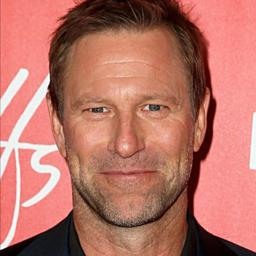

In [6]:
dataset['image'][0]

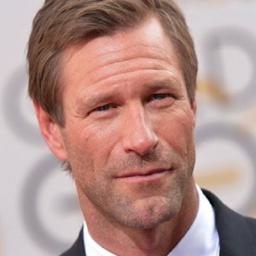

In [7]:
dataset['image'][2]

In [8]:
test_similarity(dataset['image'][0],dataset['image'][2])

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


np.float32(0.75861335)